In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv("sales_data.csv")

df.head()

,Date,Order_ID,Product,Category,Region,Sales,Quantity,Discount,Profit
0,2025-11-24,ORD1001,Phone,Electronics,North,1226,1,5,158.28
1,2025-12-13,ORD1002,Printer,Office Supplies,North,2518,2,15,219.05
2,2025-04-22,ORD1003,Chair,Furniture,West,2565,9,0,521.91
3,2025-04-23,ORD1004,Pen,Stationery,South,1239,10,0,305.96
4,2025-12-24,ORD1005,Notebook,Stationery,East,1238,6,5,157.68


In [3]:
numeric_df = df.select_dtypes(include=["number"])

numeric_df.head()

,Sales,Quantity,Discount,Profit
0,1226,1,5,158.28
1,2518,2,15,219.05
2,2565,9,0,521.91
3,1239,10,0,305.96
4,1238,6,5,157.68


In [4]:
correlation = numeric_df.corr(method="pearson")

print(correlation)

             Sales  Quantity  Discount    Profit
Sales     1.000000 -0.132854  0.176402  0.824810
Quantity -0.132854  1.000000 -0.136084 -0.103823
Discount  0.176402 -0.136084  1.000000  0.102265
Profit    0.824810 -0.103823  0.102265  1.000000


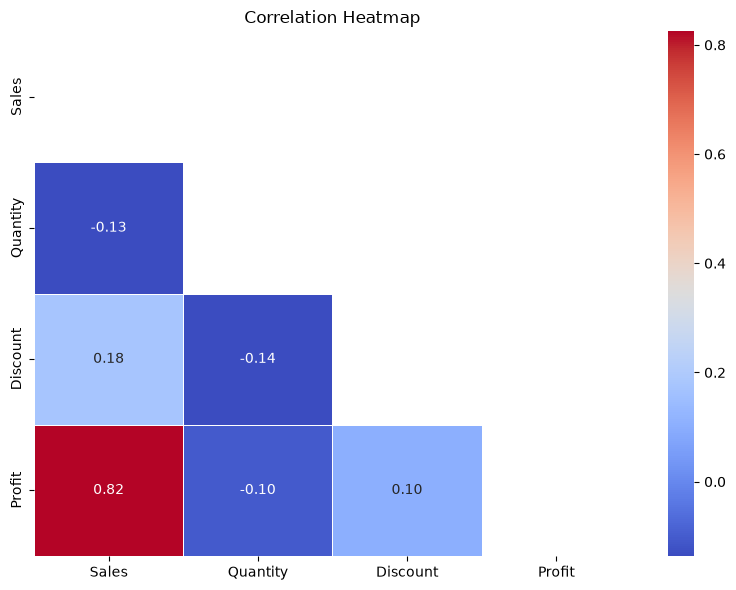

In [5]:
mask = np.triu(np.ones_like(correlation, dtype=bool))

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    mask=mask,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig("correlation_heatmap.png")

plt.show()

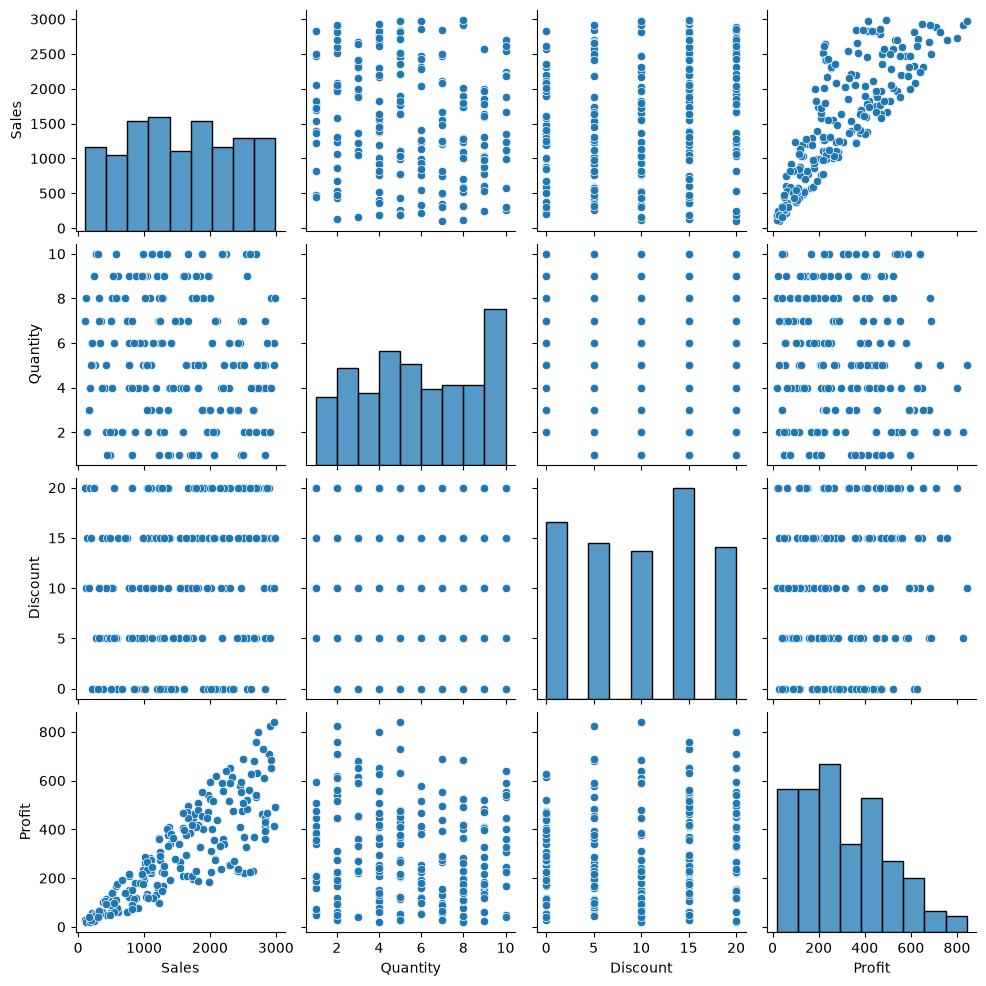

In [6]:
sns.pairplot(
    numeric_df,
    diag_kind="hist"
)

plt.savefig("pairplot.png")

plt.show()

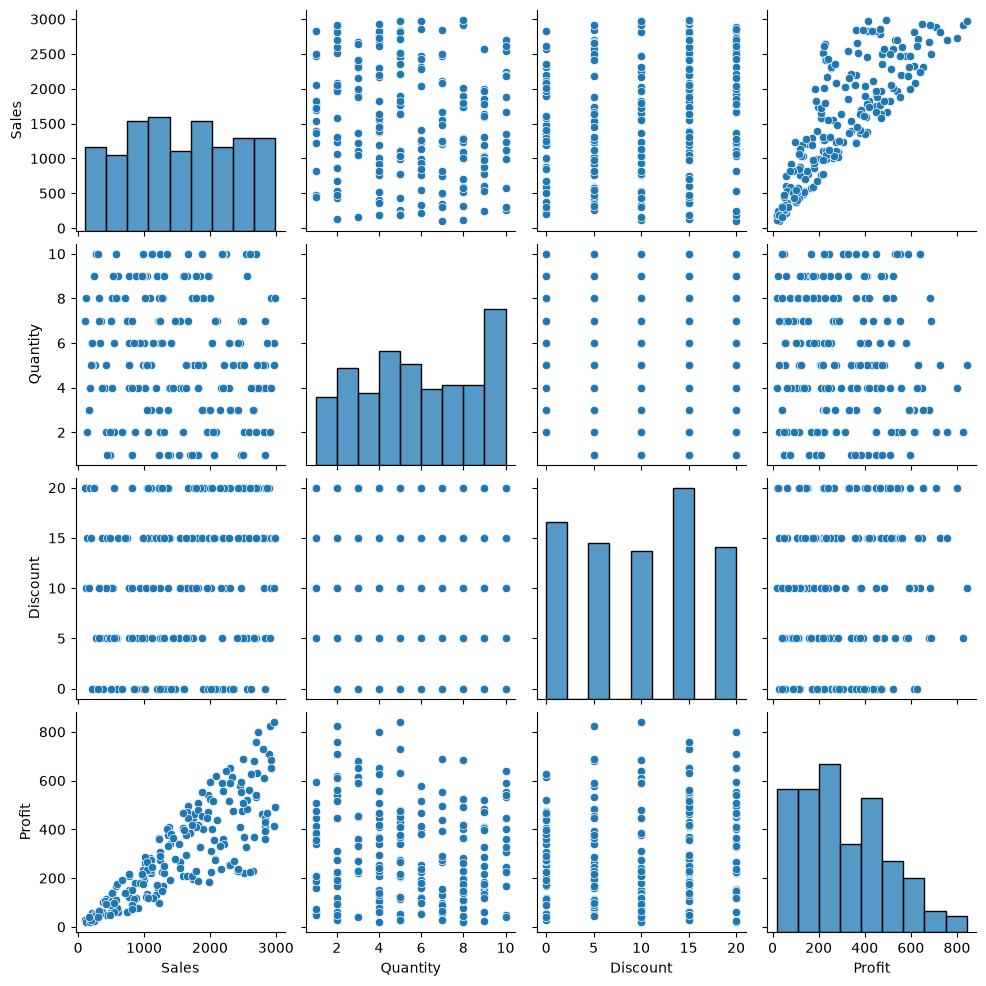

In [7]:
pair = sns.pairplot(numeric_df, diag_kind="hist")
pair.savefig("pairplot.png")
plt.show()

In [10]:
corr = correlation.copy()

corr_array = corr.to_numpy().copy()

np.fill_diagonal(corr_array, np.nan)

corr = pd.DataFrame(
    corr_array,
    index=correlation.index,
    columns=correlation.columns
)

stacked = corr.stack()

highest_positive = stacked.idxmax()
highest_negative = stacked.idxmin()

print("Highest Positive Correlation:")
print(highest_positive, "=", stacked.max())

print()

print("Highest Negative Correlation:")
print(highest_negative, "=", stacked.min())

Highest Positive Correlation:
('Sales', 'Profit') = 0.8248096820714457

Highest Negative Correlation:
('Quantity', 'Discount') = -0.13608432883180754


In [11]:
correlation.to_csv("correlation_matrix.csv")